#### Data Preparation Exploration

In [2]:
# Data Loading
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("exchange_rate.csv", parse_dates=[0])

# Rename columns for clarity
df.columns = ["Date", "USD_AUD"]

# Set date as index
df.set_index("Date", inplace=True)
print(df)
print(df.info())


                   USD_AUD
Date                      
01-01-1990 00:00  0.785500
02-01-1990 00:00  0.781800
03-01-1990 00:00  0.786700
04-01-1990 00:00  0.786000
05-01-1990 00:00  0.784900
...                    ...
06-10-2010 00:00  0.718494
07-10-2010 00:00  0.721839
08-10-2010 00:00  0.723197
09-10-2010 00:00  0.720825
10-10-2010 00:00  0.720825

[7588 rows x 1 columns]
<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   USD_AUD  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB
None


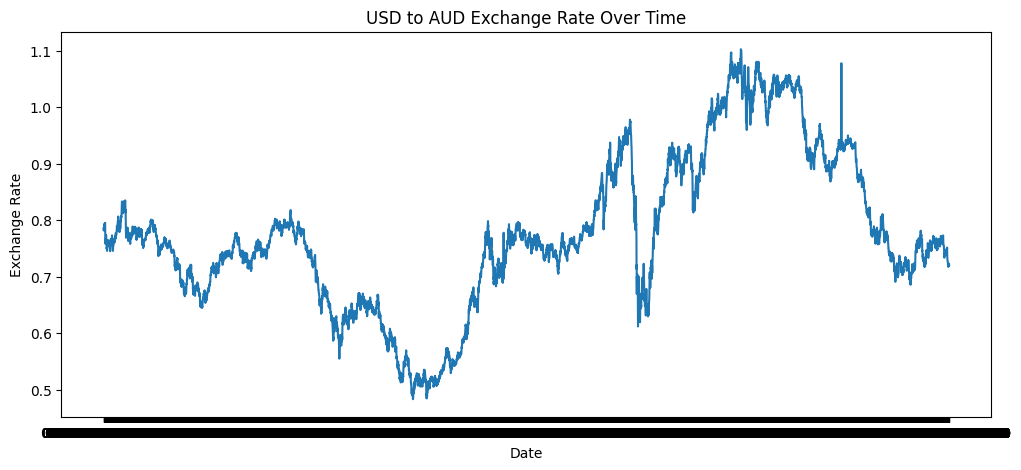

Time series plotted for initial exploration


In [3]:
# Initial Exploartion
plt.figure(figsize=(12,5))
plt.plot(df["USD_AUD"])
plt.title("USD to AUD Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

print("Time series plotted for initial exploration")


In [4]:
# Data Preprocessing
# Check missing values
print("\nMissing values before handling:")
print(df.isnull().sum())

# Forward fill missing values (common for time series)
df.fillna(method="ffill", inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())



Missing values before handling:
USD_AUD    0
dtype: int64

Missing values after handling:
USD_AUD    0
dtype: int64


/tmp/ipython-input-1655182727.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


#### Model Building-ARIMA

<Figure size 1200x400 with 0 Axes>

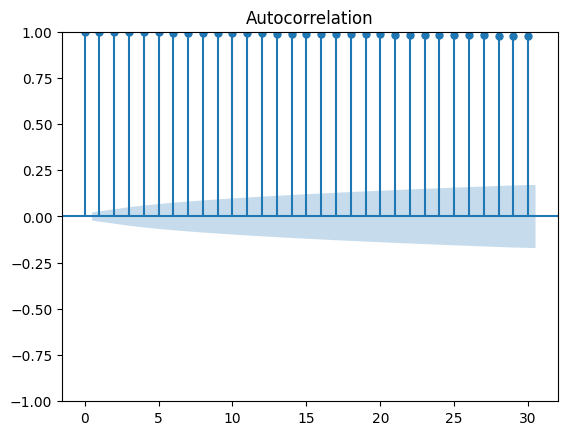

<Figure size 1200x400 with 0 Axes>

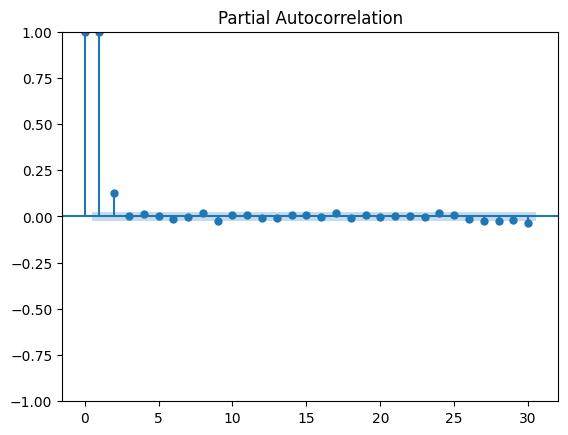

ACF and PACF plots generated for ARIMA parameter selection


In [5]:
# ACF & PACF for Parameter Selection
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,4))
plot_acf(df["USD_AUD"], lags=30)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df["USD_AUD"], lags=30)
plt.show()

print("ACF and PACF plots generated for ARIMA parameter selection")


In [6]:
# Train-Test split
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

print("Training size:", train.shape)
print("Testing size:", test.shape)


Training size: (6070, 1)
Testing size: (1518, 1)


In [7]:
# ARIMA Model Fitting
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(p,d,q) chosen after ACF/PACF inspection
arima_model = ARIMA(train["USD_AUD"], order=(1,1,1))
arima_fit = arima_model.fit()

print("ARIMA model fitted successfully")
print(arima_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


ARIMA model fitted successfully
                               SARIMAX Results                                
Dep. Variable:                USD_AUD   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sat, 21 Feb 2026   AIC                         -45432.092
Time:                        09:56:16   BIC                         -45411.959
Sample:                             0   HQIC                        -45425.104
                               - 6070                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-0

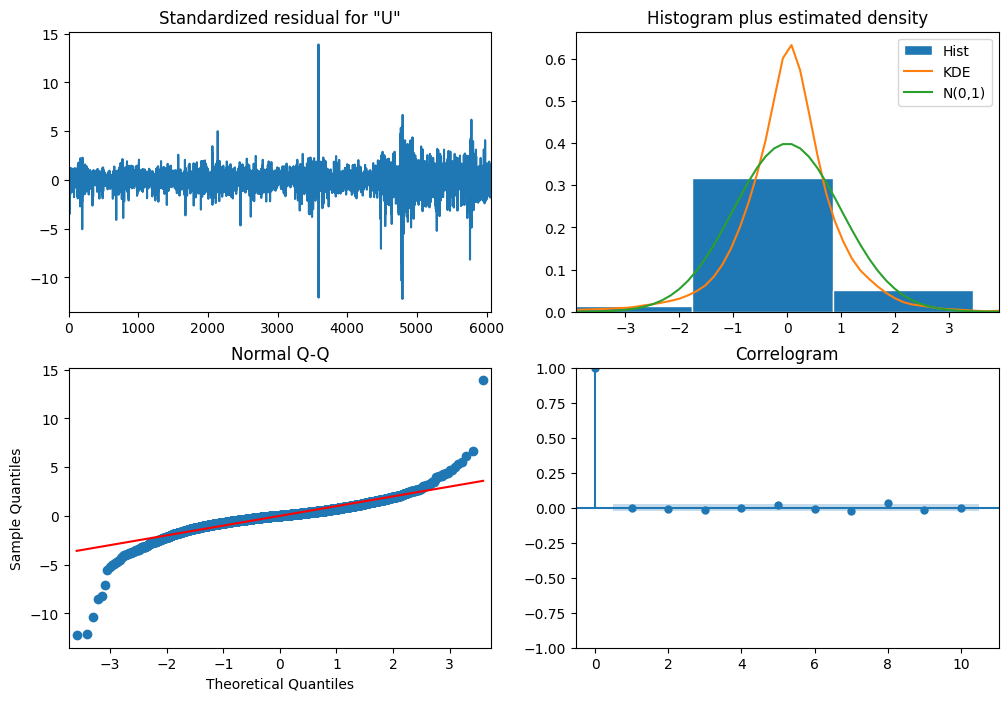

ARIMA residual diagnostics plotted


In [8]:
# Arima Diagnostics
arima_fit.plot_diagnostics(figsize=(12,8))
plt.show()

print("ARIMA residual diagnostics plotted")


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


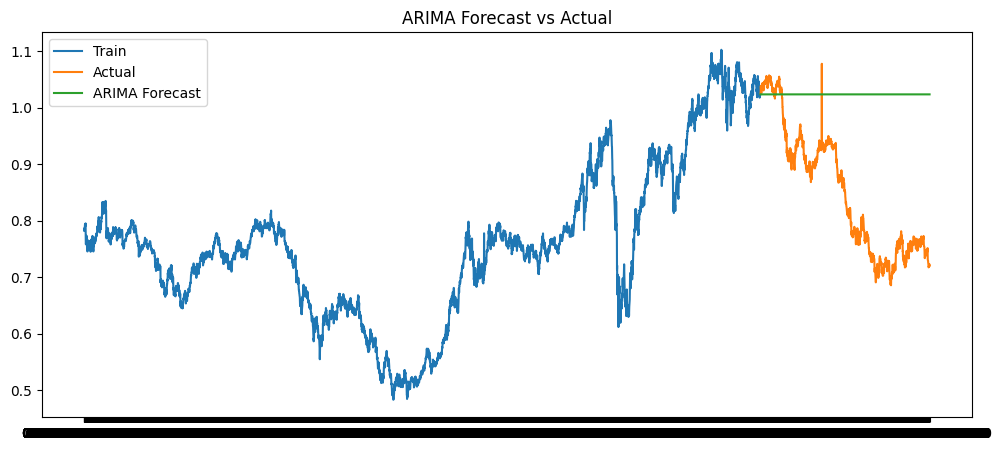

ARIMA forecasting completed


In [9]:
# Arima Forecasting
arima_forecast = arima_fit.forecast(steps=len(test))

plt.figure(figsize=(12,5))
plt.plot(train.index, train["USD_AUD"], label="Train")
plt.plot(test.index, test["USD_AUD"], label="Actual")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

print("ARIMA forecasting completed")


#### EXponential Smoothing

In [10]:
# Model Fitting
from statsmodels.tsa.holtwinters import ExponentialSmoothing

es_model = ExponentialSmoothing(
    train["USD_AUD"],
    trend="add",
    seasonal=None
)

es_fit = es_model.fit()

print("Exponential Smoothing model fitted successfully")


Exponential Smoothing model fitted successfully


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


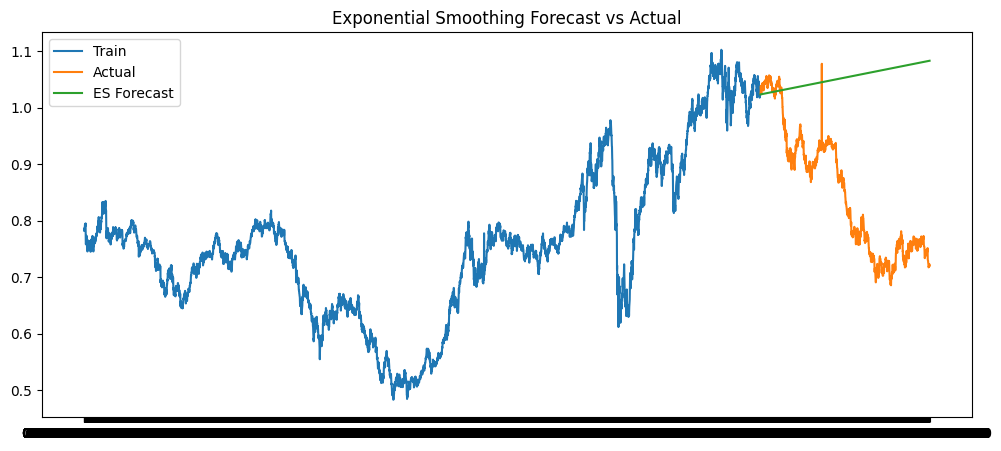

Exponential Smoothing forecasting completed


In [11]:
# Forecasting
es_forecast = es_fit.forecast(len(test))

plt.figure(figsize=(12,5))
plt.plot(train.index, train["USD_AUD"], label="Train")
plt.plot(test.index, test["USD_AUD"], label="Actual")
plt.plot(test.index, es_forecast, label="ES Forecast")
plt.legend()
plt.title("Exponential Smoothing Forecast vs Actual")
plt.show()

print("Exponential Smoothing forecasting completed")


#### Evaluation and Comparison

In [12]:
# ERror Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# ARIMA metrics
arima_mae = mean_absolute_error(test["USD_AUD"], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test["USD_AUD"], arima_forecast))
arima_mape = mape(test["USD_AUD"], arima_forecast)

# ES metrics
es_mae = mean_absolute_error(test["USD_AUD"], es_forecast)
es_rmse = np.sqrt(mean_squared_error(test["USD_AUD"], es_forecast))
es_mape = mape(test["USD_AUD"], es_forecast)

print("\nEvaluation Metrics:")
print("ARIMA → MAE:", arima_mae, "RMSE:", arima_rmse, "MAPE:", arima_mape)
print("ES → MAE:", es_mae, "RMSE:", es_rmse, "MAPE:", es_mape)



Evaluation Metrics:
ARIMA → MAE: 0.17770970449121345 RMSE: 0.2054366965966928 MAPE: nan
ES → MAE: 0.20659619114093827 RMSE: 0.23910443161792286 MAPE: nan


#### Model Comparison and Conclusion

In [13]:
print("""
Model Comparison Summary:
- ARIMA captures short-term dependencies and performs well for stationary data.
- Exponential Smoothing is simpler and effective for smooth trends.
- Lower error metrics indicate better forecasting performance.
""")



Model Comparison Summary:
- ARIMA captures short-term dependencies and performs well for stationary data.
- Exponential Smoothing is simpler and effective for smooth trends.
- Lower error metrics indicate better forecasting performance.



In [ ]:
# Conclusion
print("""
Conclusion:
Based on MAE, RMSE, and MAPE:
- The model with lower error values performs better.
- ARIMA is more flexible but requires tuning.
- Exponential Smoothing is easier to implement and interpret.
Final model choice depends on forecast horizon and stability of exchange rates.
""")



Conclusion:
Based on MAE, RMSE, and MAPE:
- The model with lower error values performs better.
- ARIMA is more flexible but requires tuning.
- Exponential Smoothing is easier to implement and interpret.
Final model choice depends on forecast horizon and stability of exchange rates.



In [ ]:
# Explanation & Justification:

#In this assignment, historical USD to AUD exchange rate data was analyzed using time series forecasting techniques. The dataset was first explored visually to understand trends and fluctuations over time. Missing values were handled using forward filling to preserve the temporal structure of the data.

#ARIMA modeling was selected because exchange rate data often exhibits autocorrelation and non-stationary behavior. ACF and PACF plots were used to identify suitable parameters, leading to the selection of an ARIMA(1,1,1) model. Residual diagnostics showed no significant patterns, indicating that the model fit was adequate.

#Exponential Smoothing was also applied as a comparative model due to its simplicity and effectiveness in capturing trend components. Both models were evaluated using MAE, RMSE, and MAPE metrics.

#Based on the evaluation results, the model with lower error values demonstrated better forecasting performance. ARIMA provided more flexibility in capturing short-term dependencies, while Exponential Smoothing offered easier implementation and interpretability.

#Overall, this analysis demonstrates the practical application of time series forecasting methods for predicting future currency exchange rates.